## Processing WebNLG Graphs
- English test file (3 references per input, 1779 graphs, 5150 texts)
- Extract entities, properties and triples
- add corresponding columns to dataframe + nb of triples, entities and properties per graph
- compute distribution of properties
- visualise 50 most frequent and 20 least frequent properties using bar chart

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('wnlg_en_test.csv')

In [4]:
df.shape #: (5150, 3)

(1779, 4)

In [ ]:
df.columns #: 'Graph', 'Test'

Index(['Unnamed: 0', 'ids', 'Text', 'Graph'], dtype='object')

In [11]:
df

,Unnamed: 0,ids,Text,Graph
0,0,Id1,"['\n', 'Estádio_Municipal_Coaracy_da_Mata_Fons...",['Estádio Municipal Coaracy da Mata Fonseca is...
1,1,Id2,"['\n', 'Nie_Haisheng | birthDate | 1964-10-13'...","['Nie Haisheng, born on October 13, 1964, work..."
2,2,Id3,"['\n', 'MotorSport_Vision | city | Fawkham', '...",['MotorSport Vision is located in the city of ...
3,3,Id4,"['\n', 'Aleksandr_Prudnikov | height | 185.0 (...",['185 centimetre tall Aleksandr Prudnikov play...
4,4,Id5,"['\n', 'Ciudad_Ayala | populationMetro | 17775...",['Ciudad Ayala is a city with population densi...
...,...,...,...,...
1774,1774,Id1775,"['\n', 'English_Without_Tears | writer | Anato...",['English Without Tears is written by Anatole ...
1775,1775,Id1776,"['\n', 'Nurhan_Atasoy | birthPlace | Turkey', ...","[""Nurhan Atasoy's birthplace is Turkey."", 'The..."
1776,1776,Id1777,"['\n', 'GMA_New_Media | location | GMA_Network...",['GMA New Media is a company in the entertainm...
1777,1777,Id1778,"['\n', 'Turn_Me_On_(album) | genre | Punk_blue...",['The Honeymoon killers produced a punk blues ...


In [4]:
### Get first row

In [5]:
g = df.loc[0,"Graph"]
g

'[\'Estádio Municipal Coaracy da Mata Fonseca is the name of the ground of Agremiação Sportiva Arapiraquense in Arapiraca. Agremiação Sportiva Arapiraquense, nicknamed "Alvinegro", lay in the Campeonato Brasileiro Série C league from Brazil.\', \'Estádio Municipal Coaracy da Mata Fonseca is the name of the ground of Agremiação Sportiva Arapiraquense in Arapiraca. Alvinegro, the nickname of Agremiação Sportiva Arapiraquense, play in the Campeonato Brasileiro Série C league from Brazil.\']'

In [19]:
df.loc[0,"Text"]

'[\'\\n\', \'Estádio_Municipal_Coaracy_da_Mata_Fonseca | location | Arapiraca\', \'\\n\', \'Agremiação_Sportiva_Arapiraquense | league | Campeonato_Brasileiro_Série_C\', \'\\n\', \'Campeonato_Brasileiro_Série_C | country | Brazil\', \'\\n\', \'Agremiação_Sportiva_Arapiraquense | nickname | "\\\'\\\'Alvinegro"\', \'\\n\', \'Agremiação_Sportiva_Arapiraquense | ground | Estádio_Municipal_Coaracy_da_Mata_Fonseca\', \'\\n\']'

In [23]:
nb_graphs = len(df["Graph"].unique())
nb_texts = len(df["Text"].unique())
f"There are {nb_graphs} graphs and {nb_texts} texts in the WebNLG English test set"

'There are 1779 graphs and 1779 texts in the WebNLG English test set'

### Add columns for 
- RDF entities, properties and triples
- Their number per graph

In [ ]:
import re

In [ ]:
# Property  = any char which is not < ,  is after <P> and before \n or <O
property_pattern = re.compile(r"\<P\>([^\<]+)(?=\<O)")
property_pattern.findall(g)

[]

In [14]:
# Entities  = any char which is not < ,  is after <O> or <S> and before \n or <P
entity_pattern = re.compile(r"\<[^P]\>([^\<]+)(?=\n|\<P)")
entity_pattern = re.compile(r'(?:<O>|<S>)[^<]*(?=\n|<P>)')
entity_pattern.findall(g)

[]

In [10]:
en_prop_triples =[]

for index, row in df.iterrows():
    graph = row["Graph"]
    entities = entity_pattern.findall(str(graph))
    nb_entities = len(entities)
    
    properties = property_pattern.findall(graph)
    nb_properties = len(properties)
    
    triples = graph.split("\n")
    nb_triples = len(triples)
    
    sentences = row["Text"].split(".")
    tokens = row["Text"].split(" ")
    
    nb_sentences = len(sentences)
    nb_tokens = len(tokens)
    
    en_prop_triples.append( (row.Graph, entities,nb_entities, properties,nb_properties, triples, nb_triples, row.Text, 
                             sentences,tokens,nb_sentences,nb_tokens))

df_split_graph = pd.DataFrame(en_prop_triples, 
                              columns=["Graph","Entities","Nb Entities","Properties","Nb Properties",
                                       "Triples","Nb Triples","Text","Sentences",
                                       "Tokens","Nb Sentences","Nb Tokens"] )

df_split_graph["Nb Triples"].describe()

count    5150.000000
mean        3.192233
std         1.701432
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: Nb Triples, dtype: float64

In [12]:
en_prop_triples =[]

for index, row in df.iterrows():
    graph = row["Graph"]
    entities = entity_pattern.findall(str(graph))
    nb_entities = len(entities)
    
    properties = property_pattern.findall(graph)
    nb_properties = len(properties)
    
    triples = graph.split("\n")
    nb_triples = len(triples)
    
    sentences = row["Text"].split(".")
    tokens = row["Text"].split(" ")
    
    nb_sentences = len(sentences)
    nb_tokens = len(tokens)
    
    en_prop_triples.append( (row.Graph, entities,nb_entities, properties,nb_properties, triples, nb_triples, row.Text, 
                             sentences,tokens,nb_sentences,nb_tokens))

df_split_graph = pd.DataFrame(en_prop_triples, 
                              columns=["Graph","Entities","Nb Entities","Properties","Nb Properties",
                                       "Triples","Nb Triples","Text","Sentences",
                                       "Tokens","Nb Sentences","Nb Tokens"] )

df_split_graph["Nb Triples"].describe()

count    1779.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: Nb Triples, dtype: float64

In [11]:
#df_split_graph["Nb Sentences"].describe()

### Get Vocabulary and vocabulary size
- set of entities, properties and triples
- their size

In [12]:
# sum(list, []) flattens a list of lists
l = [[1,2],[5]]
sum(l,[])

[1, 2, 5]

In [13]:
# Triples

triples = sum(df_split_graph["Triples"].to_list(),[])
num_triples = len(triples)
distinct_triples = set(triples)
num_distinct_triples = len(distinct_triples)
f"There are {num_triples} triples and {num_distinct_triples} distinct triples"

'There are 16440 triples and 770 distinct triples'

In [14]:
# entities
entities = sum(df_split_graph["Entities"].to_list(),[])
num_entities = len(entities)
distinct_entities = set(entities)
num_distinct_entities = len(distinct_entities)
f"There are {num_entities} entities and {num_distinct_entities} distinct entities"

'There are 27730 entities and 659 distinct entities'

In [15]:
# Properties
properties = sum(df_split_graph["Properties"].to_list(),[])
num_properties = len(properties)
distinct_properties = set(properties)
num_distinct_properties = len(distinct_properties)
f"There are {num_properties} properties and {num_distinct_properties} distinct properties"

'There are 16440 properties and 220 distinct properties'

In [16]:
df = properties.sort()
#properties
df

### Frequency distribution

In [17]:
# Compute the frequency distribution from the list of property occurrences
from collections import Counter
data = Counter(properties)
len(data)

220

#### Get n most frequent properties

In [18]:
s = pd.Series(data=properties)
top5 = s.value_counts()[:5]
top5

 birth place     756
 location        575
 birth date      554
 genre           501
 country         467
dtype: int64

In [21]:
# and generates an ASCII bar chart that reflects that frequency.
def print_ascii_bar_chart(data, symbol="#"):
    counter = Counter(data).most_common()
    chart = {category: symbol * frequency for category, frequency in counter}
    max_len = max(len(category) for category in chart)
    for category, frequency in chart.items():
        padding = (max_len - len(category)) * " "
        print(f"{category}{padding} |{frequency}")

In [23]:
print_ascii_bar_chart(data)

 birth place                                 |####################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################
 location                                    |#######################################################################################################################################################

<BarContainer object of 50 artists>

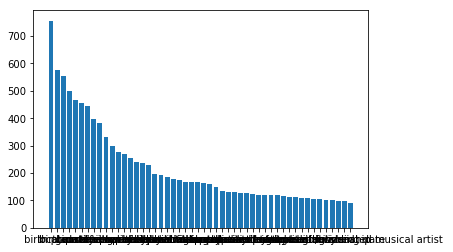

In [24]:
import matplotlib.pyplot as plt

#sales = Counter(banana=15, tomato=4, apple=39, orange=30).most_common()
# use zip() to unzip the content of sales into two variables
x, y = zip(*data.most_common(50))
plt.bar(x, y)

<BarContainer object of 50 artists>

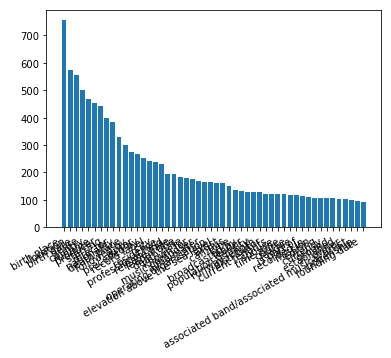

In [25]:
import matplotlib.pyplot as plt

#sales = Counter(banana=15, tomato=4, apple=39, orange=30).most_common()
# use zip() to unzip the content of sales into two variables
x, y = zip(*data.most_common(50))
plt.xticks(rotation=30, ha='right')
plt.bar(x, y)

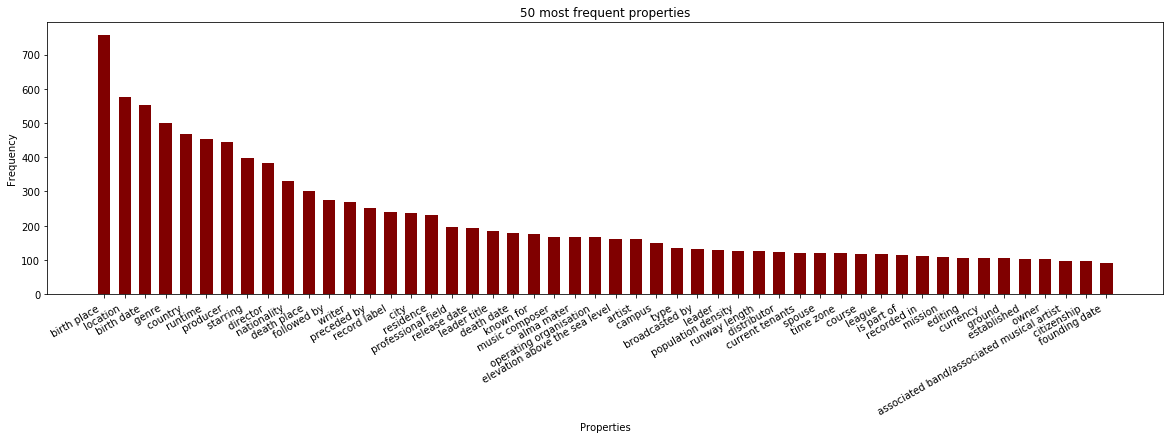

In [26]:
fig = plt.figure(figsize = (20, 5))
 
# creating the bar plot
plt.bar(x, y, color ='maroon', 
        width = 0.6)
 
plt.xlabel("Properties")
plt.ylabel("Frequency")
plt.title("50 most frequent properties")
plt.xticks(rotation=30, ha='right')
plt.show()

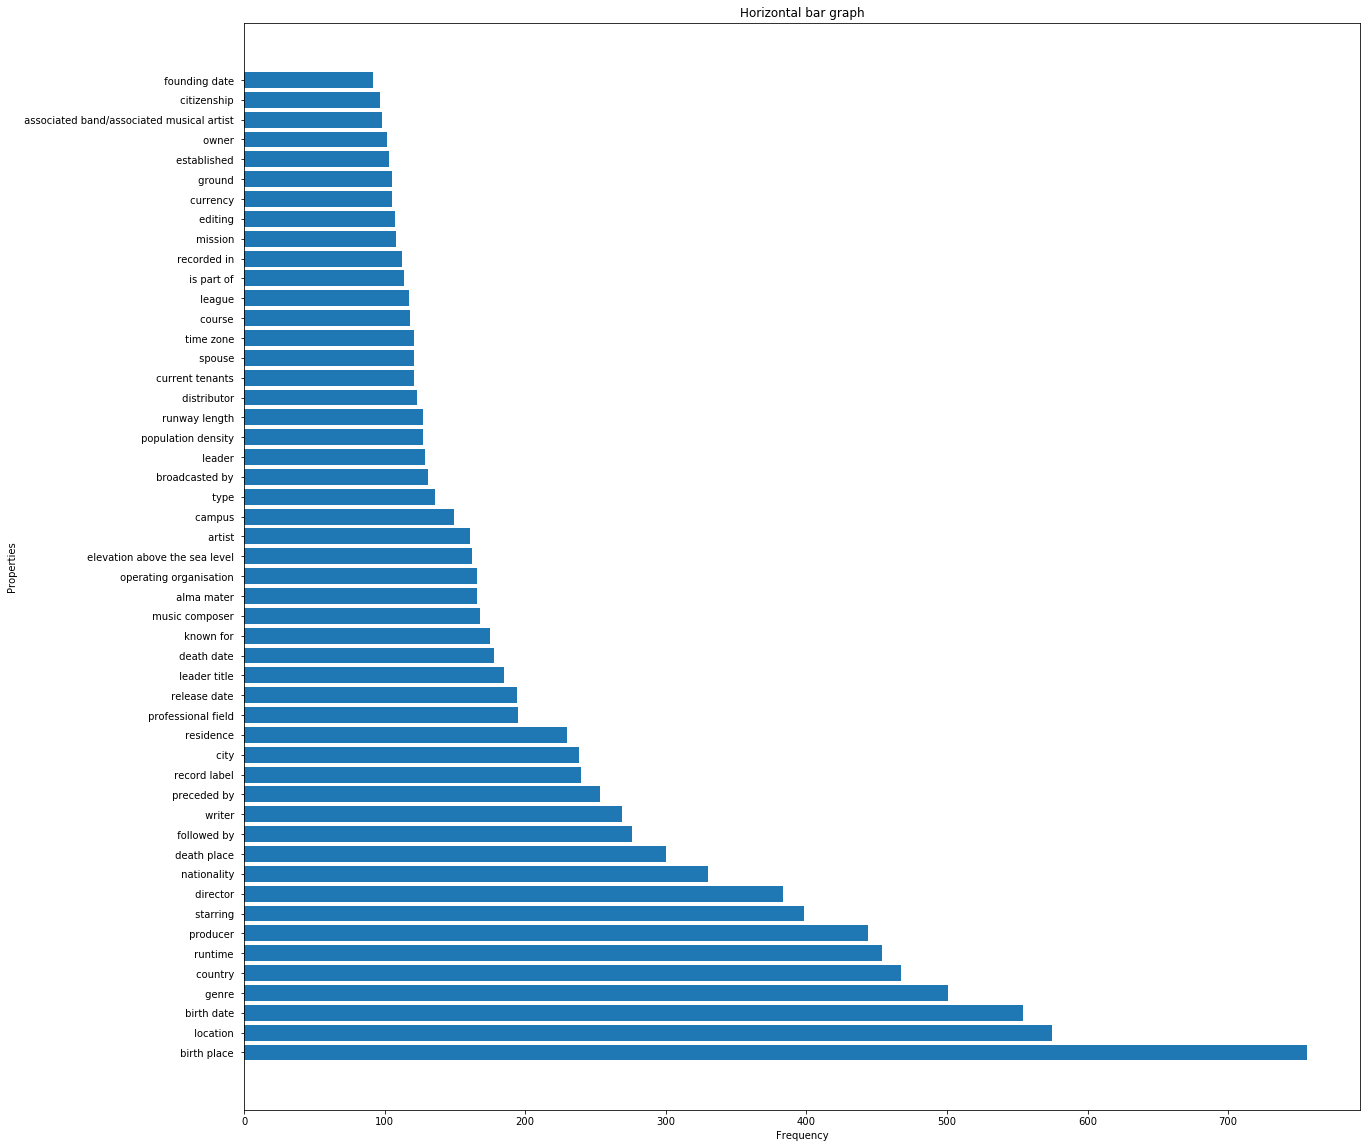

In [27]:
# Horizontal bar plot
fig = plt.figure(figsize = (20, 20))

plt.barh(x, y)

# setting label of y-axis
plt.ylabel("Properties")

# setting label of x-axis
plt.xlabel("Frequency") 
plt.title("Horizontal bar graph")
plt.show()


In [28]:
x, y = zip(*data.most_common(50)[:-20:-1])

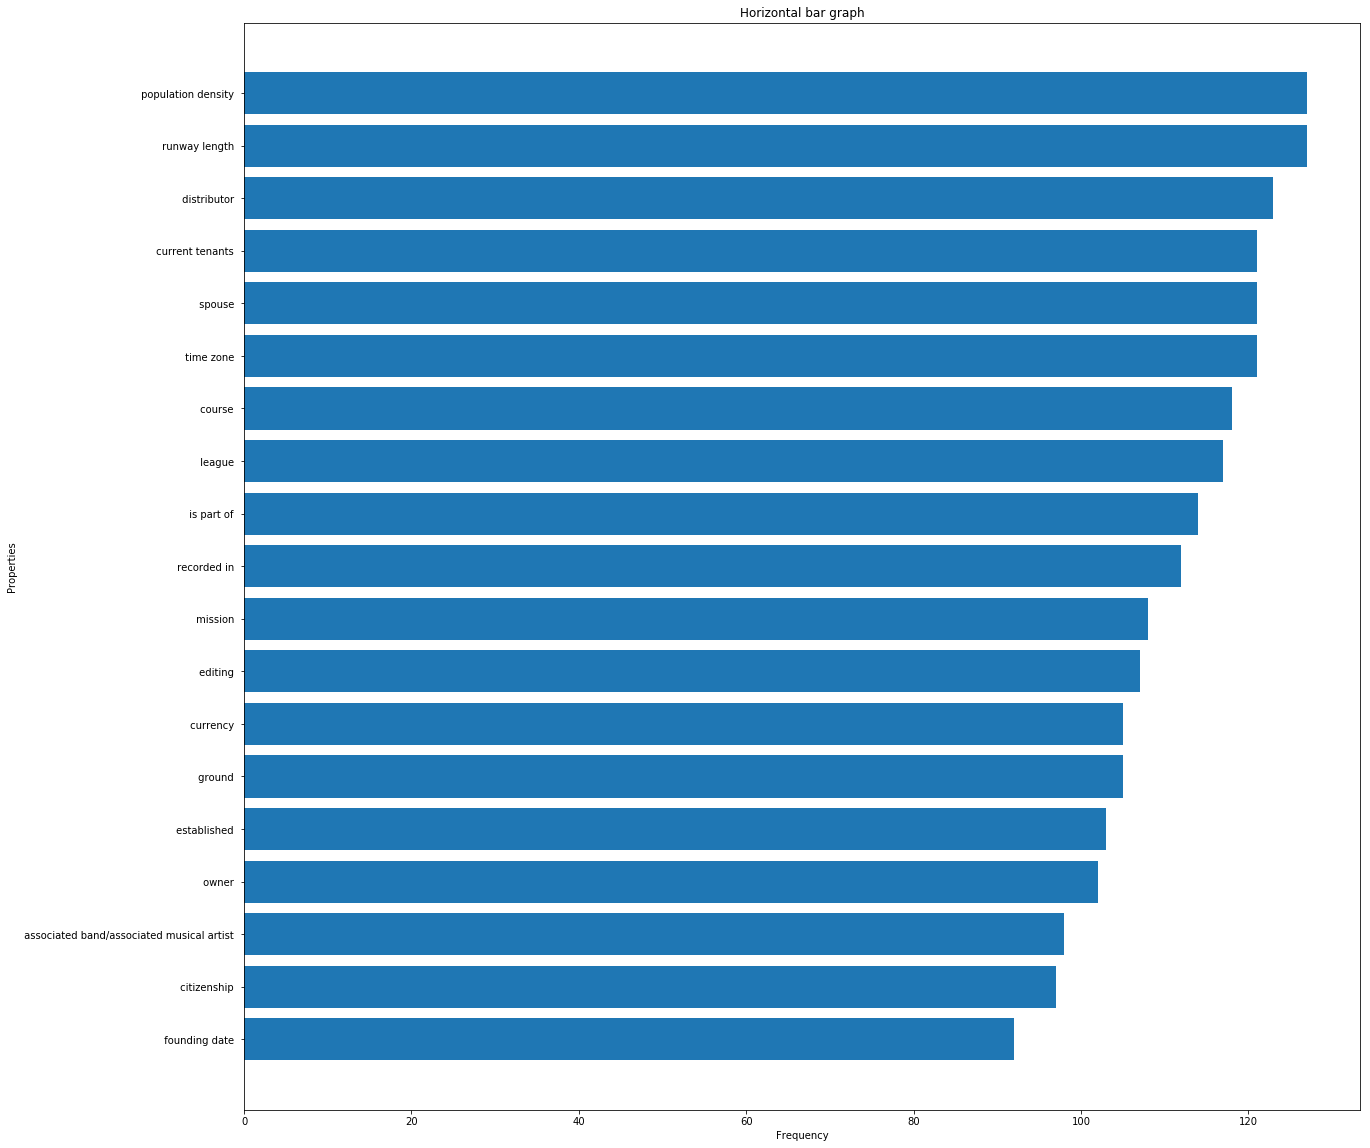

In [29]:
# Horizontal bar plot
fig = plt.figure(figsize = (20, 20))

plt.barh(x, y)

# setting label of y-axis
plt.ylabel("Properties")

# setting label of x-axis
plt.xlabel("Frequency") 
plt.title("Horizontal bar graph")
plt.show()


### Tokens and sentences using naive tokenization and sentence segmentation

In [31]:
# Tokens
tokens = sum(df_split_graph["Tokens"].to_list(),[])
num_tokens = len(tokens)
distinct_tokens = set(tokens)
num_distinct_tokens = len(distinct_tokens)
f"There are {num_tokens} tokens and {num_distinct_tokens} distinct tokens"

'There are 113196 tokens and 5127 distinct tokens'

In [32]:
# Sentences
sentences = sum(df_split_graph["Sentences"].to_list(),[])
num_sentences = len(sentences)
distinct_sentences = set(sentences)
num_distinct_sentences = len(distinct_sentences)
f"There are {num_sentences} sentences and {num_distinct_sentences} distinct sentences"

'There are 14415 sentences and 7725 distinct sentences'

In [33]:
len(sentences)

14415

In [34]:
sentence_dist = Counter(sentences).most_common()
for s in sentence_dist:
    print(f"Sentence: {s[0]} \noccurs: {s[1]} times\n\n")

Sentence:  
occurs: 5137 times


Sentence: 0 
occurs: 102 times


Sentence: R 
occurs: 99 times


Sentence:  G 
occurs: 52 times


Sentence: Abraham A 
occurs: 52 times


Sentence: M 
occurs: 51 times


Sentence: 5 
occurs: 51 times


Sentence: A 
occurs: 41 times


Sentence:  P 
occurs: 37 times


Sentence:  Sarvapalli Radhakrishnan Road, Hessarghatta Main Road, Bangalore - 560090 
occurs: 33 times


Sentence: 6 days 
occurs: 25 times


Sentence: Alan B 
occurs: 22 times


Sentence: S 
occurs: 21 times


Sentence:  M 
occurs: 20 times


Sentence:  Stern 
occurs: 18 times


Sentence:  Sarvapalli Radhakrishnan Road, Hessarghatta Main Road, Bangalore – 560090 
occurs: 17 times


Sentence: P 
occurs: 15 times


Sentence: 8 millimetres 
occurs: 14 times


Sentence:  Prabhukumar 
occurs: 14 times


Sentence: J 
occurs: 12 times


Sentence:  Tolkien 
occurs: 12 times


Sentence: 6 
occurs: 12 times


Sentence: 0 AU 
occurs: 12 times


Sentence: The College of William and Mary is the owner of

Sentence:  Ribicoff was born in the United States where African Americans are a national ethnic group 
occurs: 1 times


Sentence:  He was married to Ruth Ribicoff and was succeeded by Anthony J 
occurs: 1 times


Sentence: The literary genre of The Hobbit is juvenile fantasy 
occurs: 1 times


Sentence: The Hobbit's genre is juvenile fantasy 
occurs: 1 times


Sentence: The Hobbit is classified in the juvenile fantasy genre of literature 
occurs: 1 times


Sentence: The dessert, Binignit, comes from the Philippines 
occurs: 1 times


Sentence: The binignit dish, a type of dessert, can be found in the Philippines 
occurs: 1 times


Sentence: Binignit is a dessert that comes from the Philippines 
occurs: 1 times


Sentence: 308 kg and was born in Gdynia, Poland 
occurs: 1 times


Sentence: It's Great to Be Young (1956, 94 minutes) is a film edited by Max Benedict, who has been active in the film industry since 1947 
occurs: 1 times


Sentence:  The director of the movie is Cyril Frankel


Sentence:  He was chosen by NASA in 1959 and became Chief of the Astronaut Office in 1963 
occurs: 1 times


Sentence:  He was awarded the Distinguished Service Medal by the US Navy 
occurs: 1 times


Sentence: The John Lennon song Imagine is produced by Phil Spector, but The Train song Mermaid, which is followed by the song Imagine, was produced by the Espionage production team 
occurs: 1 times


Sentence: The song Mermaid by Train (produced by the production team Espionage) was followed by the release of Imagine by John Lennon (which was produced by Phil Spector) performed by Train 
occurs: 1 times


Sentence: Train followed Mermaid with Imagine, a song by John Lennon produced by Phil Spector's production team Espionage 
occurs: 1 times


Sentence: 2 meters above sea level with length of 1095 
occurs: 1 times


Sentence: 2104 above sea level with a runway length of 1095 
occurs: 1 times


Sentence: 2104 meters and has a runway length of 1095 
occurs: 1 times


Sentence: Musical grou